In [1]:
#Don't clip outlier gradients, clip loss instead. (don't clip local clip global). 

In [2]:
#https://www.cs.toronto.edu/~hinton/absps/science.pdf

In [ ]:
###Continuing from L4

In [9]:
###set up data

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline


words = open('names.txt', 'r').read().splitlines()
print(words[:8], len(words))

# vocab of char mappings against integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos, vocab_size)


##Building dataset splits
block_size = 3 

def build_dataset(words):
    
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'] 32033
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'} 27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
###class implementation of the MLP

class Linear:
    """
    torch.nn.linear (omitting devices (e.g. cuda) and dtype (e.g. float double). 
    """
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) /fan_in**0.5 #fan_in**0.5  ###commented this to show what plots do when its bad. 
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out +=  self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ({} if self.bias is None else [self.bias])

class BatchNorm1d:
    """
    torch.nn.batchnorm1d   with affine = True, track_running stats = true (device = cpu, dtype = float32). 
    """
    def __init__(self, dim, eps= 1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True #false for evaluation. 
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers (trained with a running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        #calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) #batch mean
            xvar = x.var(0, keepdim = True, unbiased = True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta ###not in pytorch but helps us plot. 
        #update the training buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta] 

class Tanh:
    """
    torch.nn.Tanh
    """
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layaer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size)
]
##classes make the layer stacking easy, its just a list called sequentially. 
#before batchnorm1d just omit it. e.g. Linear(n_hidden, n_hidden),Tanh(),
###he also does one version with Linear(bias = False)

with torch.no_grad():
    # last layer: make less confident
    #layers[-1].weight *= 0.1     #####this leads to the pink line outlier, but it stabalises. (used this when outpu layer was Linear)
    layers[-1].gamma *= 0.1 ###because output layer is a Batchnorm, 
    # all other layers have gain applied.
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 #Linear layers + tanh gain, replenishes output s.d. to same as input. - this matters less with batch normalization. 

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True
    

47551


In [11]:
# some optimization as alst time.
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batach, X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) #concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # after debugf would take out retin_graph >???
    for p in parameters:
        p.grad = None
        
    loss.backward() ####rewriting this in L5.

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay.
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    #if i >=1000:
    #    break

      0/ 200000: 3.2870
  10000/ 200000: 2.3578
  20000/ 200000: 2.1043
  30000/ 200000: 1.9646
  40000/ 200000: 2.2144
  50000/ 200000: 2.2266
  60000/ 200000: 1.7339
  70000/ 200000: 2.1749
  80000/ 200000: 2.1895
  90000/ 200000: 1.8281
 100000/ 200000: 2.3634
 110000/ 200000: 2.2015
 120000/ 200000: 2.1032
 130000/ 200000: 1.8564
 140000/ 200000: 1.8051
 150000/ 200000: 1.9258
 160000/ 200000: 1.8763
 170000/ 200000: 1.8335
 180000/ 200000: 2.2314
 190000/ 200000: 2.0513


layer 2 (      Tanh): mean -0.01, std 0.69, saturated: 14.03%
layer 5 (      Tanh): mean -0.02, std 0.72, saturated: 16.91%
layer 8 (      Tanh): mean -0.00, std 0.75, saturated: 15.75%
layer 11 (      Tanh): mean +0.02, std 0.77, saturated: 16.78%
layer 14 (      Tanh): mean -0.02, std 0.79, saturated: 18.72%


Text(0.5, 1.0, 'activation distribution')

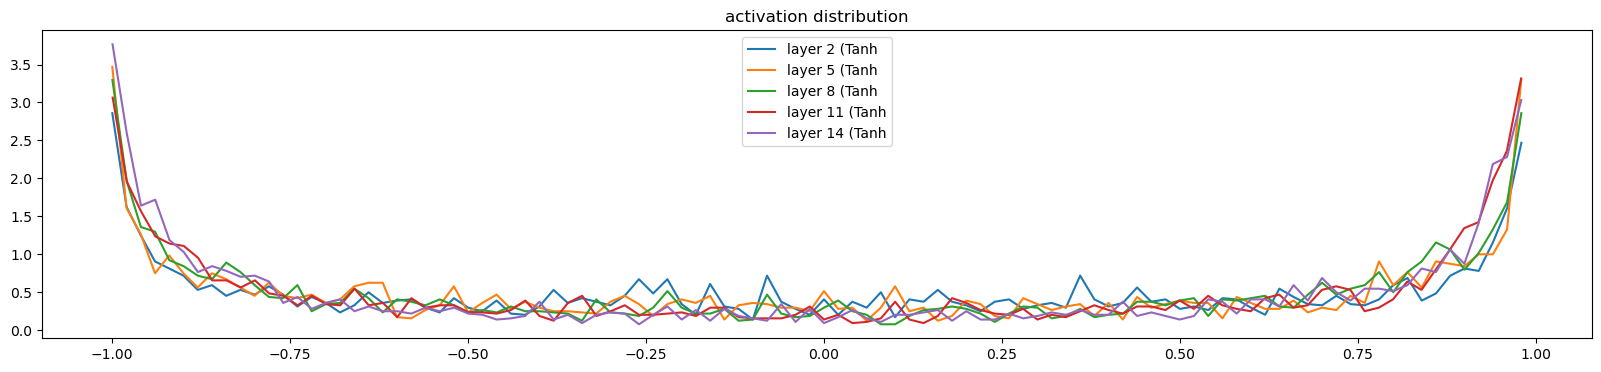

In [12]:
# visualise histograms
plt.figure(figsize = (20,4)) 
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer.
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')
             

layer 2 (      Tanh): mean -0.000000, std 3.413328e-03
layer 5 (      Tanh): mean +0.000000, std 3.279261e-03
layer 8 (      Tanh): mean -0.000000, std 3.260843e-03
layer 11 (      Tanh): mean -0.000000, std 3.532994e-03
layer 14 (      Tanh): mean -0.000000, std 3.843003e-03


Text(0.5, 1.0, 'Gradient distribution')

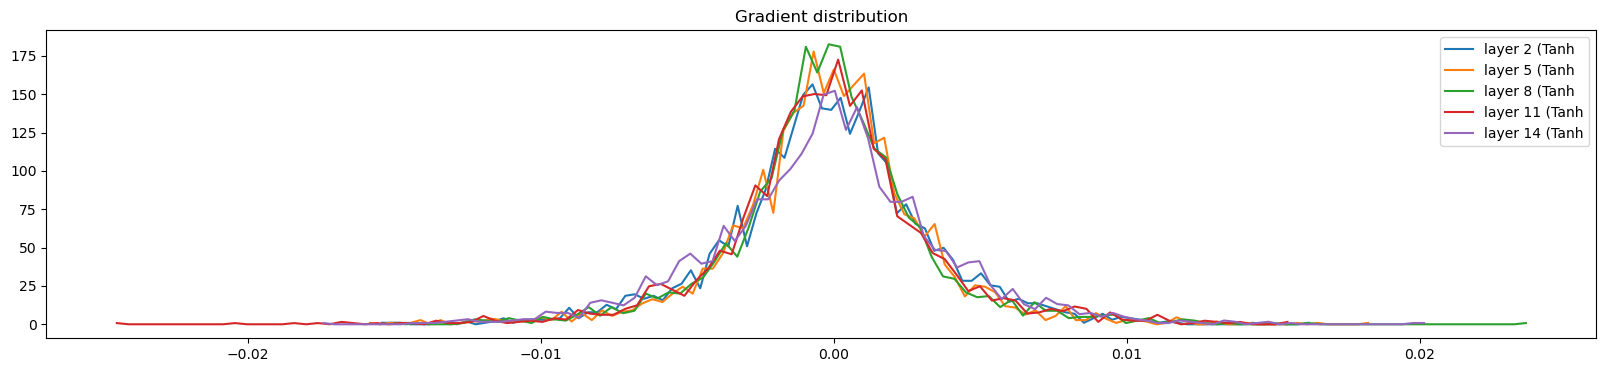

In [13]:
plt.figure(figsize = (20,4)) 
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer.
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.496318e-02 | grad:data ratio 1.370163e-02
weight  (30, 100) | mean +0.000085 | std 7.867816e-03 | grad:data ratio 1.919648e-02
weight (100, 100) | mean +0.000060 | std 5.040184e-03 | grad:data ratio 2.041886e-02
weight (100, 100) | mean -0.000086 | std 5.160316e-03 | grad:data ratio 2.125704e-02
weight (100, 100) | mean +0.000044 | std 5.189185e-03 | grad:data ratio 2.190954e-02
weight (100, 100) | mean -0.000013 | std 5.229847e-03 | grad:data ratio 2.274837e-02
weight  (100, 27) | mean +0.000052 | std 9.163456e-03 | grad:data ratio 2.774516e-02


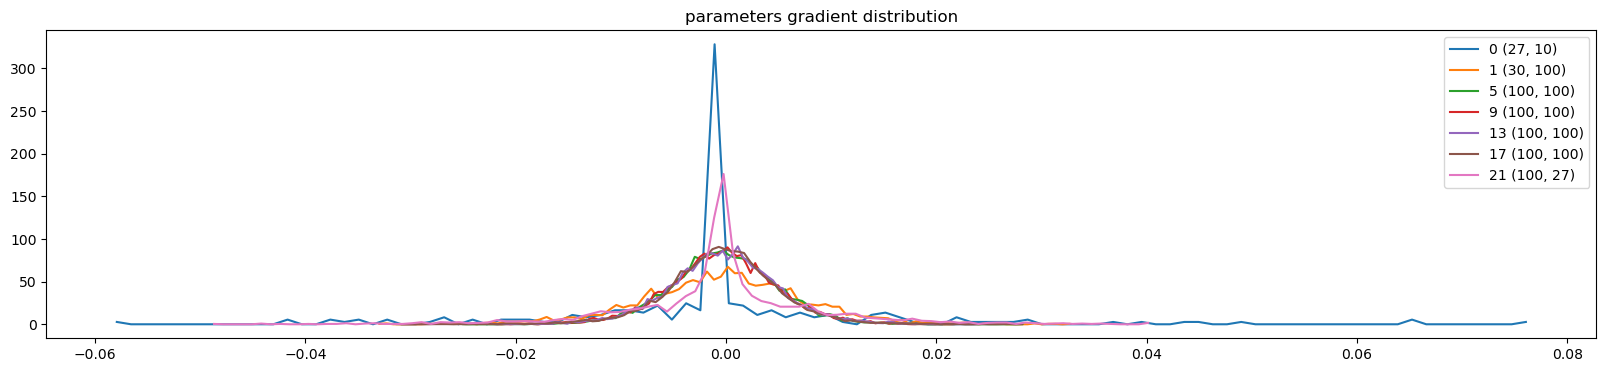

In [14]:
# visualise histograms
plt.figure(figsize = (20,4)) 
legends = []
for i,p in enumerate(parameters): 
    t = p.grad
    if p.ndim == 2:  #restricted to 2d weights of linear layer.
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('parameters gradient distribution');

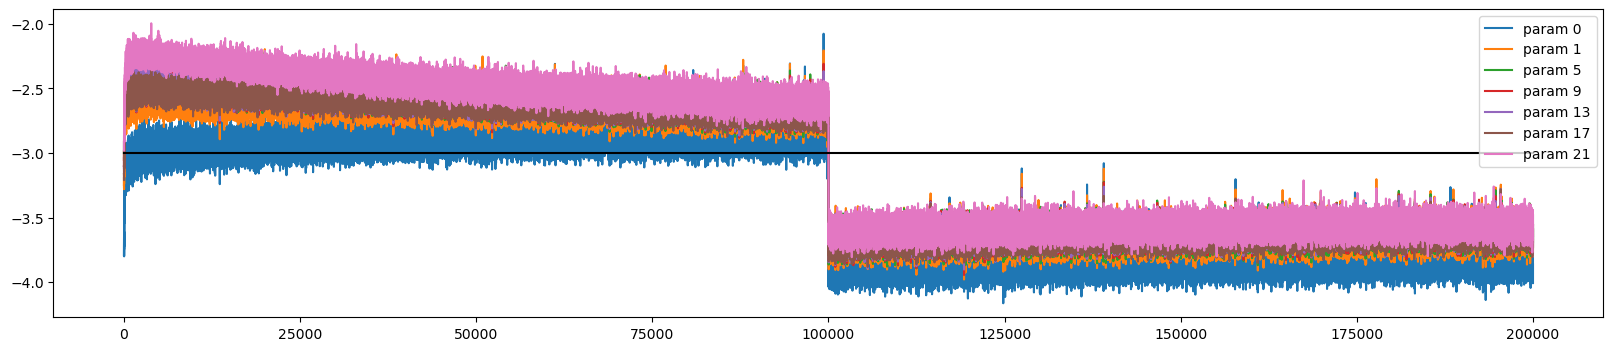

In [15]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim ==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3,-3], 'k') # these ratios should be ~1e-3, indicated on plot
plt.legend(legends);
###slow training will have values here 10,000 times smaller than the tensor size. 
#its near the black line that things are ok. 

In [16]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test' : (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # concat into (N, block_size, n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

# put layers into eval mode
for layer in layers:
    layer.training = False
    
split_loss('train')
split_loss('val')

train 2.0123209953308105
val 2.0841028690338135


In [17]:
#sample from the model
g = torch.Generator().manual_seed(2147483657)

for _ in range(20):
    out = []
    context = [0] * block_size # initialise with all...
    while True:
        # foward pass
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        x = emb.view(emb.shape[0], -1) # concatenate the vectors
        for layer in layers:
            x = layer(x) 
        logits = x
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carlah.
amelle.
khyriri.
reity.
skanya.
eja.
hube.
deliah.
jareei.
nellara.
chaiir.
kaleigh.
ham.
joce.
quintis.
lilah.
jadiquinte.
madiaryn.
kai.
eupitraylen.


In [20]:
##########################################L5 starts here

In [25]:
#- built cmp function.

def cmp(s, dt, t):
    """
    new in L5, evaluates manual gradients against pytorch.
    """
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [26]:
##need to build network manually to backprop the loop
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [87]:
###chunkating the forward pass so that its possible to backward propagate by hand.

batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y


####for layer in layers:

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) #concatenate the vectors

#Linear 1    
hprebn = embcat @ W1 + b1 
#Batch normalisation
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction is 1/(n-1)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
#Hidden layer -> Non-linearity 
h = torch.tanh(hpreact) 
#Linear 2 -> output
logits = h @ W2 + b2
#cross entropy
logit_maxes = logits.max(1, keepdims = True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability.
counts = norm_logits.exp() 
counts_sum = counts.sum(1, keepdims = True)
counts_sum_inv = counts_sum**-1 ##(not sure why 1.0/counts_sum isn't the same as pytorch but this is...)
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()



#torch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, norm_logits, logit_maxes, logits, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()
loss.backward()
loss


tensor(2.0034, grad_fn=<NegBackward0>)

In [ ]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

In [90]:
###consider how to diffentiate each one.

#e.g. logprobs  depends on n and Yb, which is the training answers. 

logprobs[range(32), Yb]

tensor([-2.6406, -1.0157, -0.6764, -2.7274, -1.4198, -4.9605, -2.7274, -0.3394,
        -1.7842, -3.4866, -2.7565, -1.8614, -1.2742, -1.2825, -1.3920, -1.8281,
        -2.6406, -2.0419, -1.8428, -1.9104, -0.5415, -1.2910, -1.5800, -2.3632,
        -2.3824, -2.4455, -2.6687, -3.4829, -1.7807, -2.6687, -1.0675, -1.2275],
       grad_fn=<IndexBackward0>)

In [94]:
logprobs.shape
#loss = -1/3a + -1/3b + -1/3c
#dloss/da = -1/n

torch.Size([32, 27])

In [93]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
cmp('logprobs', dlogprobs, logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


In [96]:
##log nodes in micrograd.  d(lnx)/dx = 1/x
#dprobs = chain rule.. (1/probs) * dlogprobs.

dprobs = (1.0 / probs) * dlogprobs
cmp('probs', dprobs, probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


In [97]:
counts.shape, counts_sum_inv.shape

(torch.Size([32, 27]), torch.Size([32, 1]))

In [118]:
#c = a * b
#3x3 @ 3x1 = 3x3. 

#think about the micrograd when a gradients sum for a nodes uses in backpropogation
#therefore sum accross rows. 

dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


In [121]:
#chainrule. 

dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


In [124]:

# a11 a12 a13 ---> b1(a11, a12, a13)
# a21 a22 a23 ---> b2(a21, a22, a23)
# a31 a32 a33 ---> b3(a31, a32, a33) , broadcasting of 1,27 B matrix inputs add onto the chain rule constribution. 


dcounts = counts_sum_inv * dprobs
dcounts += torch.ones_like(counts) * dcounts_sum
cmp('counts', dcounts, counts)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


In [126]:
#norm_lgotis = logits - logit_maxes = h @ W2 + b2 - max(h @ W2 + b2) 

#elementwise exp of dlogits. 
#local derivative * global derivative. 

dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


In [127]:
norm_logits.shape, logits.shape, logit_maxes.shape

(torch.Size([32, 27]), torch.Size([32, 27]), torch.Size([32, 1]))

In [129]:
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
cmp('logit_maxes', dlogit_maxes, logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


In [130]:
### shapes aren't the same so careful with broadcasting.

#Cmat = Amat - bcol  copy the dnorm logits

dlogits = dnorm_logits.clone()
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes ##logits max is a func of logits so more chain rule. 

cmp('logits', dlogits, logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


In [132]:
dlogits.shape, h.shape, W2.shape, b2.shape #broadcasts to 32, 27

(torch.Size([32, 27]),
 torch.Size([32, 200]),
 torch.Size([200, 27]),
 torch.Size([27]))

In [134]:
dh = dlogits @ W2.T    ##h @ W2 + b2 --> 
cmp('h', dh, h)

h               | exact: True  | approximate: True  | maxdiff: 0.0


In [135]:
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0


In [137]:
# dtanhx/dx = sech^2 x = 1-tanh^2 x.  (trig ID).
dhpreact = (1.0 - h**2) * dh
cmp('hpreact', dhpreact, hpreact)

hpreact         | exact: True  | approximate: True  | maxdiff: 0.0


In [140]:
bngain.shape, bnraw.shape, dhpreact.shape, bnbias.shape

(torch.Size([1, 200]),
 torch.Size([32, 200]),
 torch.Size([32, 200]),
 torch.Size([1, 200]))

In [138]:
##similar problem to before (but note the mult is elementwise *.  then chain rule + broadcasting checks. 

dbngain = (bnraw * dhpreact).sum(0, keepdim=True) #each rows sum backwards to contribute to the gain. 
dbnraw = bngain * dhpreact # 
dbnbias = dhpreact.sum(0, keepdim=True)

cmp('bngain', dbngain, bngain)
cmp('bnraw', dbnraw, bnraw)
cmp('bnbias', dbnbias, bnbias)


bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0


In [144]:
bnraw.shape, bndiff.shape, bnvar_inv.shape

(torch.Size([32, 200]), torch.Size([32, 200]), torch.Size([1, 200]))

In [156]:
#batch bnmeani is the sum . 
#bnvar is the sigma square ( i.e. bndiff is sqaured and summed). 


#broadcasting in the forward pass (bndiff=hprebn-bnmeani_) leads to variable reuse. 
dbndiff = bnvar_inv * dbnraw

dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True) #to make the dimensionality fit use sum. 
###a sum in the forward pass turns into a replication in a backward pass. 

cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

bnvar_inv       | exact: True  | approximate: True  | maxdiff: 0.0


In [159]:
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv   #  #
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar   ###bessel's approx is unbiased estimator for the variance (small data= batches). 
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)

bnvar           | exact: True  | approximate: True  | maxdiff: 0.0
bndiff2         | exact: True  | approximate: True  | maxdiff: 0.0


In [160]:
#calculus power rule d x**n dx = n x**(n-1)
dbndiff += (2*bndiff) * dbndiff2    ### chain rule twice (+=), because it branches back into bnvar_inv. 
cmp('bndiff', dbndiff, bndiff)

bndiff          | exact: True  | approximate: True  | maxdiff: 0.0


In [161]:


dhprebn = dbndiff.clone() #sum in forward pass, replicates.   ##hprebn = embcat @ W1 + b1 # hidden layer pre-activation

dbnmeani = (-dbndiff).sum(0) # bnmeani = 1/n*hprebn.sum(0, keepdim=True), sums lead to clones. 

dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani) #

cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)



bnmeani         | exact: True  | approximate: True  | maxdiff: 0.0
hprebn          | exact: True  | approximate: True  | maxdiff: 0.0


In [163]:
hprebn.shape, embcat.shape, W1.shape, b1.shape

(torch.Size([32, 200]),
 torch.Size([32, 30]),
 torch.Size([30, 200]),
 torch.Size([200]))

In [167]:
dembcat = dhprebn @ W1.T  ## matmul calculus, shapes
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape) ##just recast into original shape, no real gradient for a concatenation (shape manipulation). 

cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)

embcat          | exact: True  | approximate: True  | maxdiff: 0.0
W1              | exact: True  | approximate: True  | maxdiff: 0.0
b1              | exact: True  | approximate: True  | maxdiff: 0.0
emb             | exact: True  | approximate: True  | maxdiff: 0.0


In [168]:
emb.shape, embcat.shape, C.shape

(torch.Size([32, 3, 10]), torch.Size([32, 30]), torch.Size([27, 10]))

In [173]:
print(Xb[:5], '\n',emb.shape, C.shape, Xb.shape)

tensor([[ 0,  0,  0],
        [ 0,  0, 11],
        [ 4,  9, 24],
        [ 0,  0,  0],
        [ 0,  1, 21]]) 
 torch.Size([32, 3, 10]) torch.Size([27, 10]) torch.Size([32, 3])


In [175]:
#indexing operation, 

dC = torch.zeros_like(C)
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
      ix = Xb[i,j]
      dC[ix] += demb[i,j] ##rows may have been reused so +=.

cmp('C', dC, C)

C               | exact: True  | approximate: True  | maxdiff: 0.0


In [176]:
####ANSWERS...

##differntials of all of the parameters that lead to backward pass.

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff += (2*bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]
    
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)


logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [179]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

####he's overkilled the splits above.. you can use calculus and skip lots of steps. 
#logits = h @ W2 + b2

# slow loss(above):
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# fast loss:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

2.0033788681030273 diff: 0.0


In [182]:
# backward pass
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


In [183]:
###good enough... 

In [184]:
logits.shape

torch.Size([32, 27])

In [185]:
 Yb.shape

torch.Size([32])

In [186]:
F.softmax(logits, 1)[0]

tensor([0.0006, 0.1298, 0.0245, 0.0654, 0.0506, 0.0341, 0.0075, 0.0176, 0.0308,
        0.0207, 0.0693, 0.1098, 0.0561, 0.0713, 0.0413, 0.0141, 0.0180, 0.0020,
        0.0462, 0.0666, 0.0417, 0.0020, 0.0098, 0.0049, 0.0024, 0.0161, 0.0468],
       grad_fn=<SelectBackward0>)

In [187]:
dlogits[0] * n

tensor([ 5.6265e-04,  1.2978e-01,  2.4508e-02,  6.5386e-02,  5.0561e-02,
         3.4074e-02,  7.5248e-03,  1.7606e-02,  3.0811e-02,  2.0682e-02,
         6.9343e-02,  1.0977e-01,  5.6102e-02, -9.2868e-01,  4.1310e-02,
         1.4096e-02,  1.7997e-02,  2.0350e-03,  4.6231e-02,  6.6568e-02,
         4.1740e-02,  1.9568e-03,  9.8102e-03,  4.8894e-03,  2.4269e-03,
         1.6066e-02,  4.6839e-02], grad_fn=<MulBackward0>)

In [188]:
dlogits[0].sum()

tensor(3.7253e-09, grad_fn=<SumBackward0>)

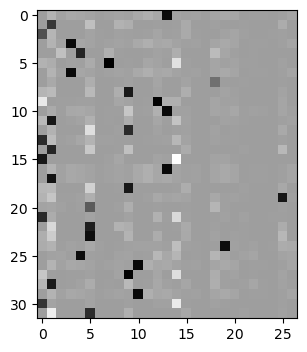

In [189]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

In [68]:
# Exercise 3: backprop through batchnorm but all in one go. #fun exercise..!

# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative wrt its input, simplify the expression, and just write it out


##Similar simplification to ex 2, you can use calculus to shorten the backprob. 

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [193]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # Good enough again.. 

hprebn          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09


In [194]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 200]),
 torch.Size([1, 200]),
 torch.Size([1, 200]),
 torch.Size([32, 200]),
 torch.Size([200]))

In [221]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written
with torch.no_grad():

  # kick off optimization
    for i in range(max_steps):

        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
        # forward pass
        emb = C[Xb] # embed the characters into vectors
        embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
        # Linear layer
        hprebn = embcat @ W1 + b1 # hidden layer pre-activation
        # BatchNorm layer
        # -------------------------------------------------------------
        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(0, keepdim=True, unbiased=True)
        bnvar_inv = (bnvar + 1e-5)**-0.5
        bnraw = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
        # -------------------------------------------------------------
        # Non-linearity
        h = torch.tanh(hpreact) # hidden layer
        logits = h @ W2 + b2 # output layer
        loss = F.cross_entropy(logits, Yb) # loss function
    
        # backward pass
        for p in parameters:
          p.grad = None
    
        # manual backprop! #swole_doge_meme
        # -----------------
        dlogits = F.softmax(logits, 1)
        dlogits[range(n), Yb] -= 1
        dlogits /= n
        # 2nd layer backprop
        dh = dlogits @ W2.T
        dW2 = h.T @ dlogits
        db2 = dlogits.sum(0)
        # tanh
        dhpreact = (1.0 - h**2) * dh
        # batchnorm backprop
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        dbnbias = dhpreact.sum(0, keepdim=True)
        dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
        # 1st layer
        dembcat = dhprebn @ W1.T
        dW1 = embcat.T @ dhprebn
        db1 = dhprebn.sum(0)
        # embedding
        demb = dembcat.view(emb.shape)
        dC = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
          for j in range(Xb.shape[1]):
            ix = Xb[k,j]
            dC[ix] += demb[k,j]
        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
        # -----------------
    
        # update
        lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
        for p, grad in zip(parameters, grads):
          #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
          p.data += -lr * grad # new way of swole doge TODO: enable
    
        # track stats
        if i % 10000 == 0: # print every once in a while
          print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        lossi.append(loss.log10().item())
    
        #if i >= 100: 
        #   break

12297
      0/ 200000: 3.8091
  10000/ 200000: 2.1868
  20000/ 200000: 2.3538
  30000/ 200000: 2.4458
  40000/ 200000: 1.9818
  50000/ 200000: 2.3578
  60000/ 200000: 2.4038
  70000/ 200000: 2.0186
  80000/ 200000: 2.3669
  90000/ 200000: 2.0425
 100000/ 200000: 2.0173
 110000/ 200000: 2.3523
 120000/ 200000: 1.9747
 130000/ 200000: 2.4591
 140000/ 200000: 2.3820
 150000/ 200000: 2.2258
 160000/ 200000: 1.9846
 170000/ 200000: 1.8659
 180000/ 200000: 1.9621
 190000/ 200000: 1.9298


In [219]:
# useful for checking your gradients
loss.backward() ####
for p,g in zip(parameters, grads):
    cmp(str(tuple(p.shape)), g, p)
# calibrate the batch norm at the end of training
##solid.

(27, 10)        | exact: False | approximate: False | maxdiff: 0.005886312574148178
(30, 200)       | exact: False | approximate: False | maxdiff: 0.001606600359082222
(200,)          | exact: False | approximate: True  | maxdiff: 4.190951585769653e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08
(27,)           | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(1, 200)        | exact: False | approximate: False | maxdiff: 0.0011330011766403913
(1, 200)        | exact: False | approximate: False | maxdiff: 0.0009404662996530533


In [222]:
with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [223]:
# evaluate train and val loss
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


#above (L4)
#train 2.0123209953308105
#val 2.0841028690338135

#solid

train 2.071009635925293
val 2.110198974609375


In [224]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    print(''.join(itos[i] for i in out))

carmahza.
jahleigh.
mri.
reytyn.
kanden.
jazonte.
delynn.
jareei.
nellara.
chaiha.
kaleigh.
ham.
joce.
quinn.
salin.
alianni.
waythoniearyn.
kai.
eveigh.
brex.
